# Level 1 - Task 3:Exploratory Data Analysis (EDA)

In [1]:
# Cell 1: Drive Mount + Library Import + Data Load
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset Load
df = pd.read_csv('/content/drive/MyDrive/Codveda Technologies Data Science task List/Data Set For Task/1) iris.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Mounted at /content/drive
Dataset Shape: (150, 5)

First 5 rows:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [2]:
# Cell 2: Summary Statistics
print("="*50)
print("SUMMARY STATISTICS")
print("="*50)
print("\nMean:\n", df.mean(numeric_only=True))
print("\nMedian:\n", df.median(numeric_only=True))
print("\nVariance:\n", df.var(numeric_only=True))
print("\nStandard Deviation:\n", df.std(numeric_only=True))
print("\nFull Description:\n")
print(df.describe())

SUMMARY STATISTICS

Mean:
 sepal_length    5.843333
sepal_width     3.054000
petal_length    3.758667
petal_width     1.198667
dtype: float64

Median:
 sepal_length    5.80
sepal_width     3.00
petal_length    4.35
petal_width     1.30
dtype: float64

Variance:
 sepal_length    0.685694
sepal_width     0.188004
petal_length    3.113179
petal_width     0.582414
dtype: float64

Standard Deviation:
 sepal_length    0.828066
sepal_width     0.433594
petal_length    1.764420
petal_width     0.763161
dtype: float64

Full Description:

       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.10000

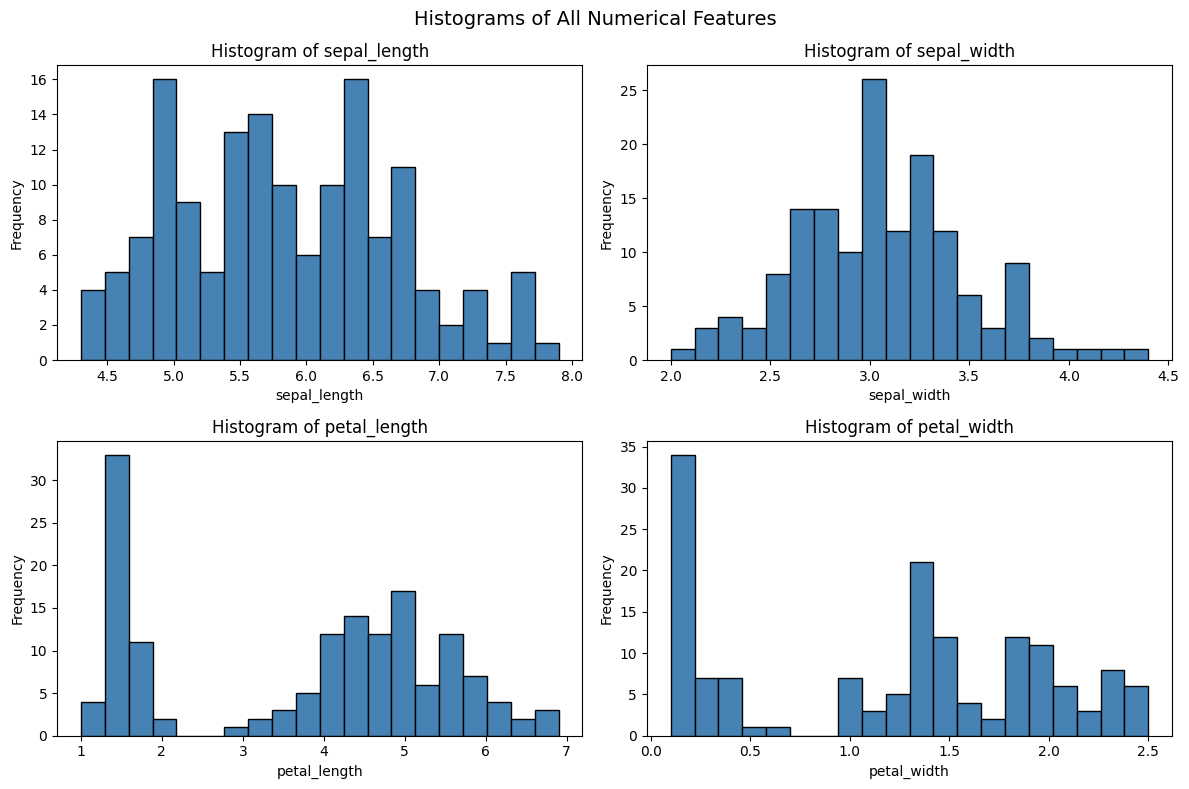

In [3]:
# Cell 3: Histogram
numerical_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(12, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    plt.hist(df[col], bins=20, color='steelblue', edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.suptitle('Histograms of All Numerical Features', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/histograms.png')
plt.show()

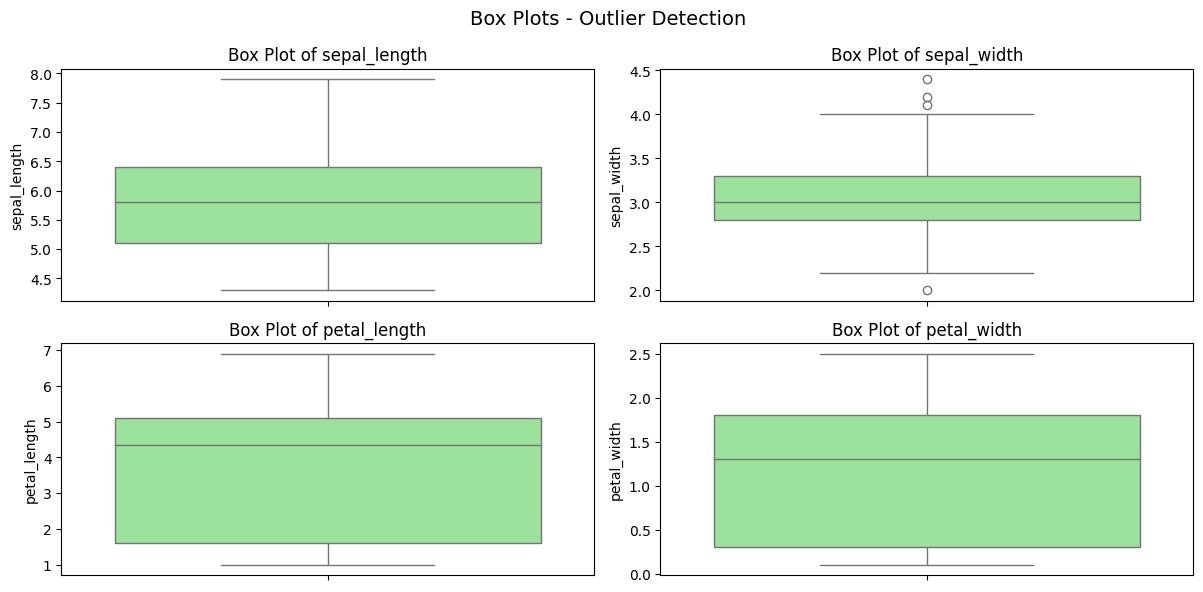

In [4]:
# Cell 4: Box Plot
plt.figure(figsize=(12, 6))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Box Plot of {col}')
plt.suptitle('Box Plots - Outlier Detection', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/boxplots.png')
plt.show()

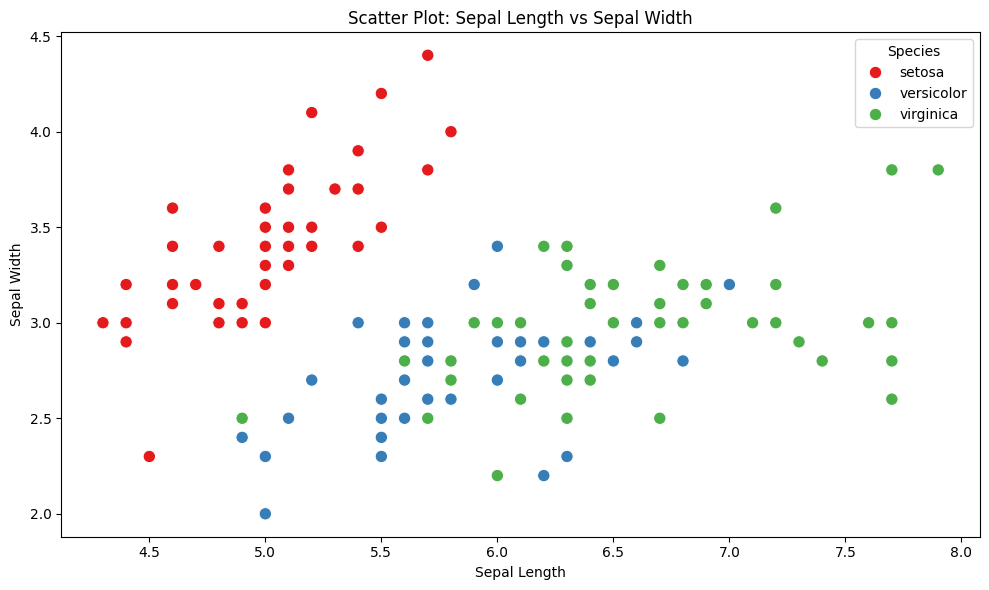

In [5]:
# Cell 5: Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='sepal_length', y='sepal_width',
                hue='species', palette='Set1', s=80)
plt.title('Scatter Plot: Sepal Length vs Sepal Width')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend(title='Species')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/scatterplot.png')
plt.show()

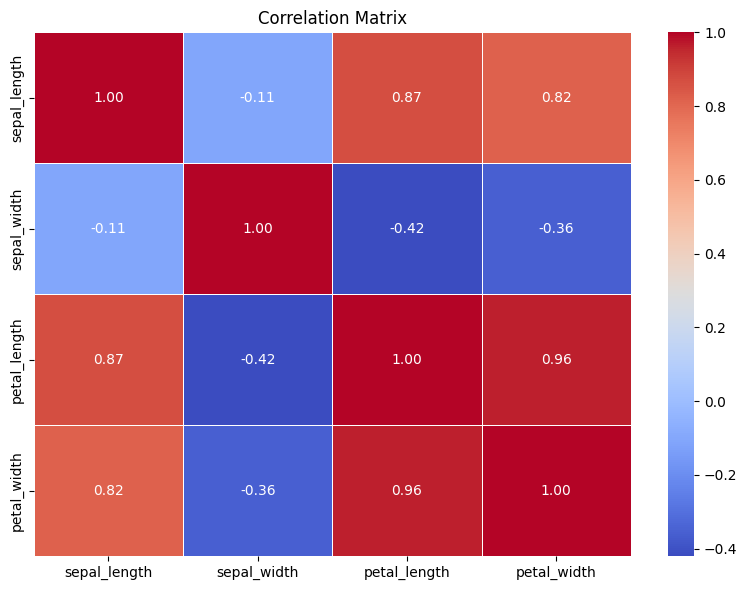


Correlation Matrix Values:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.109369      0.871754     0.817954
sepal_width      -0.109369     1.000000     -0.420516    -0.356544
petal_length      0.871754    -0.420516      1.000000     0.962757
petal_width       0.817954    -0.356544      0.962757     1.000000


In [6]:
# Cell 6: Correlation Matrix (Heatmap)
plt.figure(figsize=(8, 6))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/correlation_matrix.png')
plt.show()

print("\nCorrelation Matrix Values:")
print(corr_matrix)

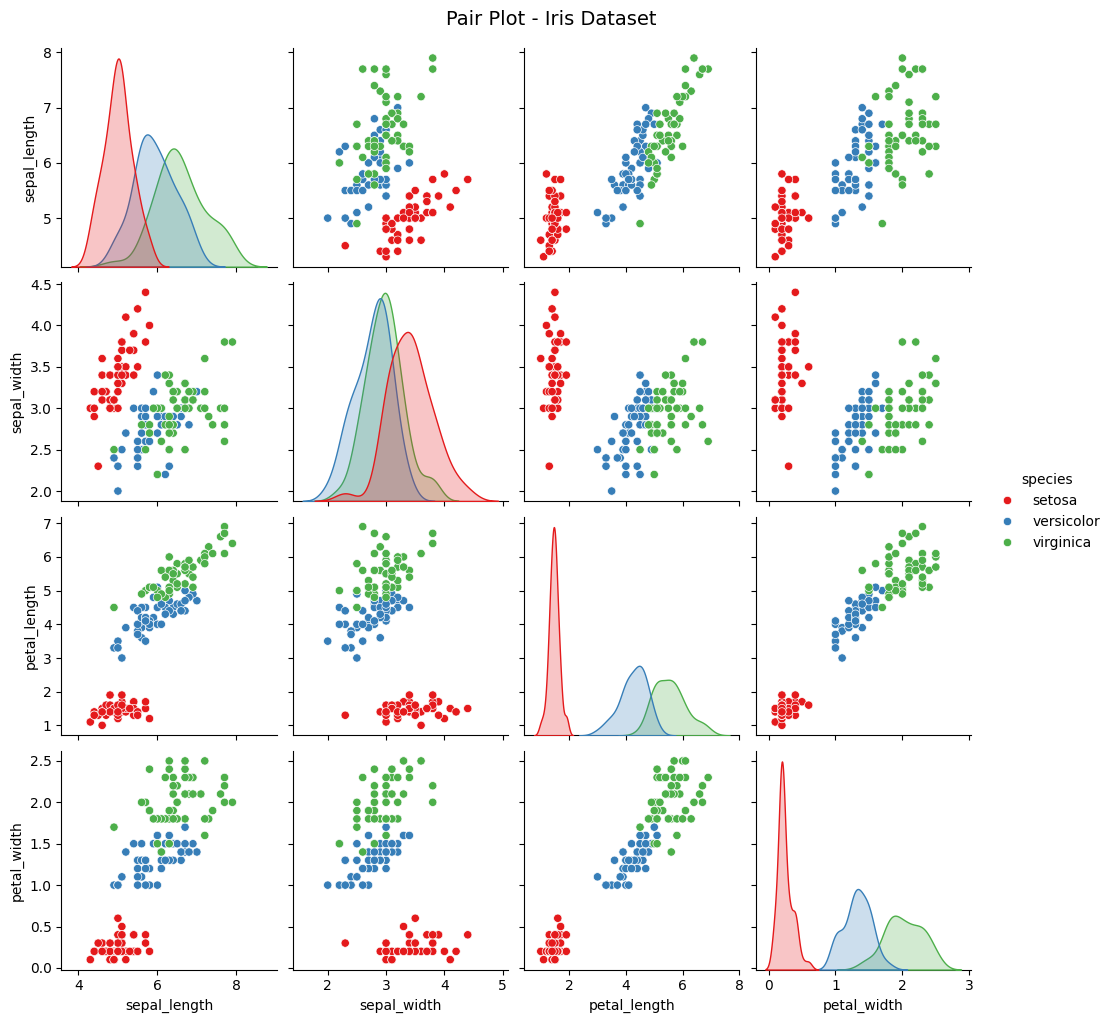

In [7]:
# Cell 7: Pair Plot
sns.pairplot(df, hue='species', palette='Set1')
plt.suptitle('Pair Plot - Iris Dataset', y=1.02, fontsize=14)
plt.savefig('/content/drive/MyDrive/pairplot.png')
plt.show()

In [9]:
# Cell 8: EDA Summary Report
print("="*60)
print("         EDA SUMMARY REPORT — IRIS DATASET")
print("="*60)
print(f"\n Total Rows    : {df.shape[0]}")
print(f" Total Columns : {df.shape[1]}")
print(f"\n Missing Values:\n{df.isnull().sum()}")
print(f"\n Species Distribution:\n{df['species'].value_counts()}")
print(f"\n Top Correlations:")
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0].sort_values(ascending=False)
print(corr_pairs.drop_duplicates().head(5))
print("\n Insight 1: petal_length & petal_width are highly correlated (0.96+)")
print(" Insight 2: Setosa species is clearly separable from others")
print(" Insight 3: Sepal width has more outliers — visible in box plot")
print("="*60)

         EDA SUMMARY REPORT — IRIS DATASET

 Total Rows    : 150
 Total Columns : 5

 Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

 Species Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

 Top Correlations:
petal_length  petal_width     0.962757
sepal_length  petal_length    0.871754
              petal_width     0.817954
sepal_width   sepal_length   -0.109369
              petal_width    -0.356544
dtype: float64

 Insight 1: petal_length & petal_width are highly correlated (0.96+)
 Insight 2: Setosa species is clearly separable from others
 Insight 3: Sepal width has more outliers — visible in box plot
